# Fixed Transmon - Readout Resonator system

This notebook studies a minimal circuit QED model built from a fixed-frequency `Transmon` and a readout-resonator `Oscillator`.

**What is covered:**
- bare transmon and resonator frequencies with their detuning
- the dressed spectrum in `HilbertSpace`
- avoided crossings induced by sweeping the resonator frequency
- bare ↔ dressed state tracking with `SpectrumLookup`
- transition, diabatic, and adiabatic views of the same avoided crossing
- dispersive-style post-processing from `chi_matrix`, `lamb_shift`, and `self_kerr`, with explicit caveats near resonance



In [1]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

## 1. Physical model

We model the capacitively coupled fixed-frequency transmon and readout resonator as:

$$\hat{H} = \hat{H}_{\mathrm{tmon}} + \omega_r \, \hat{a}^\dagger \hat{a} - ig \, \hat{n} \otimes (\hat{a} - \hat{a}^\dagger)$$

- offset charge $n_g$ can be added

Here the transmon is represented by `Transmon` and the resonator by `Oscillator`. Bare labels follow the **1-based** convention, so `(1, 1)` is the ground state, `(2, 1)` is the first transmon excitation, and `(1, 2)` is the one-photon resonator state.


In [22]:
tmon = Transmon(EJ=20.0, EC=0.2, ng=0.0, ncut=18, truncated_dim=4)
osc = Oscillator(E_osc=6.6, truncated_dim=7)
g = 0.12

hs = HilbertSpace([tmon, osc])
add_interaction!(hs, g, [tmon, osc],
    [s -> n_operator(s), 
     s -> 1im * (creation_operator(s) - annihilation_operator(s))])

transition01(evals) = evals[2] - evals[1]
transition12(evals) = evals[3] - evals[2]


transition12 (generic function with 1 method)

## 2. Bare subsystem summary

Before turning to the coupled problem, we summarize the energy scales of the bare transmon and bare resonator. Because the transmon is fixed-frequency, `ω01` is constant and only the detuning from the initial readout-resonator frequency `ωr` is set by the working point.


In [23]:
tmon_evals = eigenvals(tmon; evals_count=4)
osc_evals = eigenvals(osc; evals_count=4)

ω01 = transition01(tmon_evals)
ω12 = transition12(tmon_evals)
α = ω12 - ω01
ωr = osc.E_osc
Δ = ω01 - ωr

(
    bare_transmon_evals_GHz = round.(tmon_evals, digits=6),
    bare_resonator_evals_GHz = round.(osc_evals, digits=6),
    ω01_GHz = round(ω01, digits=6),
    ω12_GHz = round(ω12, digits=6),
    anharmonicity_α_GHz = round(α, digits=6),
    ωr_GHz = round(ωr, digits=6),
    detuning_Δ_GHz = round(Δ, digits=6),
    coupling_g_GHz = g,
)


(bare_transmon_evals_GHz = [-17.222508, -11.773481, -6.543552, -1.548987], bare_resonator_evals_GHz = [0.0, 6.6, 13.2, 19.8], ω01_GHz = 5.449027, ω12_GHz = 5.229928, anharmonicity_α_GHz = -0.219099, ωr_GHz = 6.6, detuning_Δ_GHz = -1.150973, coupling_g_GHz = 0.12)

## 3. `HilbertSpace` construction and low-lying dressed spectrum

We now diagonalize the full composite system. Calling `generate_lookup!` lets us query the bare ↔ dressed mapping, so we can check which dressed branch corresponds to states such as `(2, 1)` or `(1, 2)`.


In [8]:
dressed_evals = eigenvals(hs; evals_count=8)
generate_lookup!(hs; evals_count=16)

(
    dressed_evals_GHz = round.(dressed_evals, digits=6),
    dressed_index_of_2_1 = dressed_index(hs, 2, 1),
    dressed_index_of_1_2 = dressed_index(hs, 1, 2),
    bare_label_of_dressed_3 = bare_index(hs, 3),
    dressed_energy_of_2_1_GHz = round(energy_by_bare_index(hs, 2, 1; subtract_ground=true), digits=6),
    dressed_energy_of_1_2_GHz = round(energy_by_bare_index(hs, 1, 2; subtract_ground=true), digits=6),
)


(dressed_evals_GHz = [-17.224545, -11.798399, -10.605648, -6.583373, -5.187201, -3.98684, -1.598232, 0.022574], dressed_index_of_2_1 = 2, dressed_index_of_1_2 = 3, bare_label_of_dressed_3 = (1, 2), dressed_energy_of_2_1_GHz = 5.426146, dressed_energy_of_1_2_GHz = 6.618897)

## 4. Bare vs dressed comparison and avoided crossing

For a fixed transmon, the qubit frequency stays constant, so the most natural sweep is the resonator frequency `E_osc`, which changes the detuning directly. As `E_osc ≈ ω01`, the `(2, 1)` and `(1, 2)` branches hybridize and form an avoided crossing.

이 섹션에서는 세 종류의 그림을 분리해서 봅니다. 왼쪽은 scqubits-style `plot_transitions(...)` 결과로, bare/dispersive labeling을 따라 강조된 transition spectrum입니다. 이 강조선은 exact adiabatic branch를 그리는 것이 아니라 bare/dispersive labeling이 살아 있는 곳을 표시합니다. 가운데는 `energy_by_bare_index(...)`로 `(2, 1)` / `(1, 2)` bare label에 붙은 dressed energies를 직접 추적한 것으로, adiabatic lower/upper branch가 아니라 diabatic bare-character tracking입니다. 오른쪽은 `energy_by_dressed_index(...)`로 고정된 dressed index `2`, `3`을 따라간 adiabatic branch로, avoided crossing의 lower/upper eigen-branches를 직접 보여줍니다.

따라서 가운데와 오른쪽 패널은 같은 곡선을 다른 색으로 그린 것이 아닙니다. 가운데는 bare-state character를, 오른쪽은 energy-ordered dressed branch를 보여주므로 avoided crossing을 통과하면서 서로 다르게 보이는 것이 정상입니다.



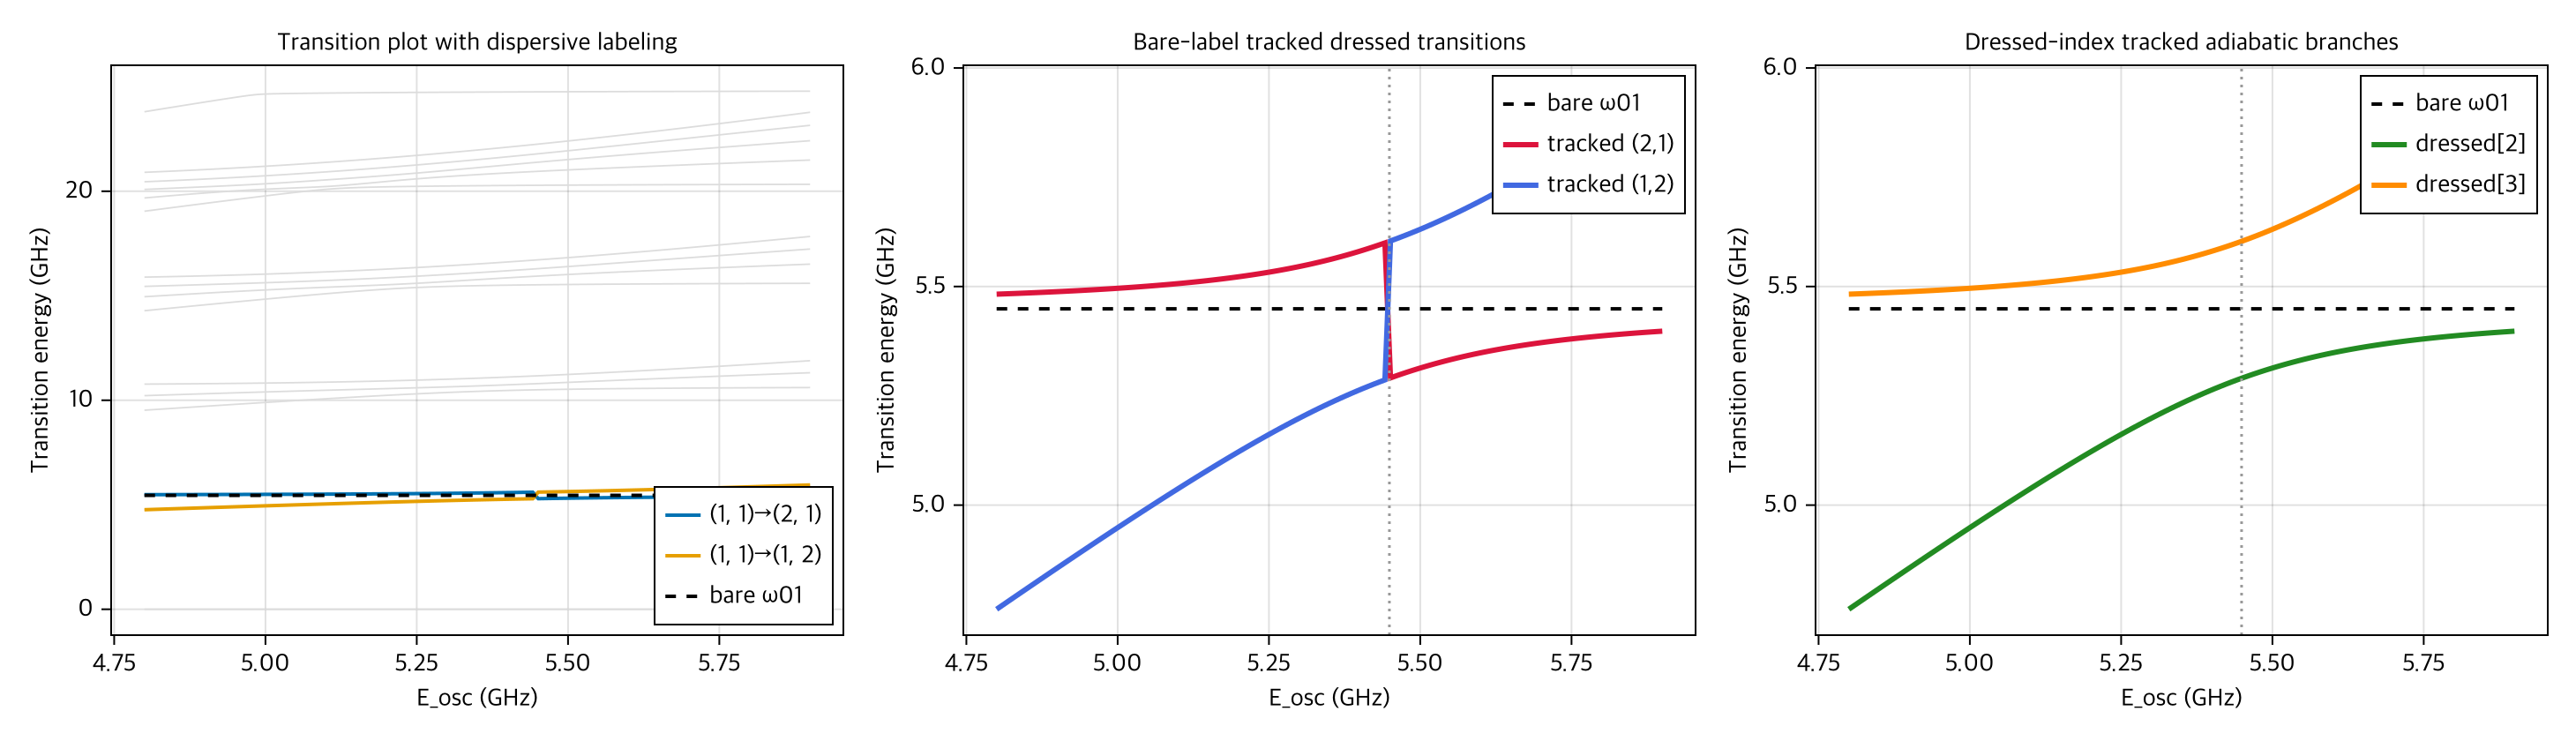

In [71]:
sweep_Eosc = collect(range(4.8, 5.9, length=121))

strict_sweep = ParameterSweep(hs,
    Dict(:E_osc => sweep_Eosc),
    (hs, vals) -> begin
        hs.subsystems[2].E_osc = vals[:E_osc]
    end;
    evals_count=16,
    store_lookups=true)

transition_slice = strict_sweep[:]
bare_w01 = fill(ω01, length(sweep_Eosc))
dressed_transmon_like = [
    energy_by_bare_index(strict_sweep, 2, 1; param_indices=(i,), subtract_ground=true)
    for i in eachindex(sweep_Eosc)
]
dressed_resonator_like = [
    energy_by_bare_index(strict_sweep, 1, 2; param_indices=(i,), subtract_ground=true)
    for i in eachindex(sweep_Eosc)
]
adiabatic_lower = [
    energy_by_dressed_index(strict_sweep, 2; param_indices=(i,), subtract_ground=true)
    for i in eachindex(sweep_Eosc)
]
adiabatic_upper = [
    energy_by_dressed_index(strict_sweep, 3; param_indices=(i,), subtract_ground=true)
    for i in eachindex(sweep_Eosc)
]

comparison_points = [1, 31, 61, 91, 121]
comparison_table = [
    (
        E_osc_GHz = round(sweep_Eosc[i], digits=3),
        bare_ω01_GHz = round(bare_w01[i], digits=6),
        dressed_transmon_like_GHz = round(dressed_transmon_like[i], digits=6),
        dressed_resonator_like_GHz = round(dressed_resonator_like[i], digits=6),
        dressed_2_GHz = round(adiabatic_lower[i], digits=6),
        dressed_3_GHz = round(adiabatic_upper[i], digits=6),
        Lamb_shift_MHz = round((dressed_transmon_like[i] - bare_w01[i]) * 1000, digits=3),
    )
    for i in comparison_points
]

fig = Figure(size=(1460, 420))
ax1 = Axis(fig[1, 1],
    xlabel="E_osc (GHz)",
    ylabel="Transition energy (GHz)",
    title="Transition plot with dispersive labeling")
plot_transitions(transition_slice; final=[(2, 1), (1, 2)], fig_ax=(fig, ax1))
lines!(ax1, sweep_Eosc, bare_w01; color=:black, linestyle=:dash, linewidth=2, label="bare ω01")
axislegend(ax1; position=:rb)

ax2 = Axis(fig[1, 2],
    xlabel="E_osc (GHz)",
    ylabel="Transition energy (GHz)",
    title="Bare-label tracked dressed transitions")
lines!(ax2, sweep_Eosc, bare_w01; color=:black, linestyle=:dash, linewidth=2, label="bare ω01")
lines!(ax2, sweep_Eosc, dressed_transmon_like; color=:crimson, linewidth=3, label="tracked (2,1)")
lines!(ax2, sweep_Eosc, dressed_resonator_like; color=:royalblue, linewidth=3, label="tracked (1,2)")
vlines!(ax2, [ω01]; color=:gray60, linestyle=:dot)
axislegend(ax2; position=:rt)

ax3 = Axis(fig[1, 3],
    xlabel="E_osc (GHz)",
    ylabel="Transition energy (GHz)",
    title="Dressed-index tracked adiabatic branches")
lines!(ax3, sweep_Eosc, bare_w01; color=:black, linestyle=:dash, linewidth=2, label="bare ω01")
lines!(ax3, sweep_Eosc, adiabatic_lower; color=:forestgreen, linewidth=3, label="dressed[2]")
lines!(ax3, sweep_Eosc, adiabatic_upper; color=:darkorange, linewidth=3, label="dressed[3]")
vlines!(ax3, [ω01]; color=:gray60, linestyle=:dot)
axislegend(ax3; position=:rt)

(fig, comparison_table)

fig



## 5. State tracking with `SpectrumLookup`

The key role of `SpectrumLookup` is that it does not treat the spectrum as a simple energy-ordered list; instead, it lets us follow the **dominant bare-state character** of each dressed state. That is different from following an adiabatic branch by fixed dressed index or by energy ordering.

Near resonance, dressed indices 2 and 3 exchange their dominant bare labels. In this notebook that behavior is expected: `SpectrumLookup` is telling us that the bare-state content swaps across the avoided crossing, not that the exact eigenspectrum itself is discontinuous.



In [72]:
track_window = findall(6.0 .<= sweep_Eosc .<= 6.3)

tracking_rows = [
    (
        E_osc_GHz = round(sweep_Eosc[i], digits=3),
        dressed_index_of_2_1 = dressed_index(strict_sweep, 2, 1; param_indices=(i,)),
        dressed_index_of_1_2 = dressed_index(strict_sweep, 1, 2; param_indices=(i,)),
        bare_label_of_dressed_2 = bare_index(strict_sweep, 2; param_indices=(i,)),
        bare_label_of_dressed_3 = bare_index(strict_sweep, 3; param_indices=(i,)),
    )
    for i in track_window
]

tracking_rows


Any[]

## 6. Dispersive post-processing: `χ`, Lamb shift, self-Kerr`

This sweep intentionally crosses the resonant region, so the quantities below are **not** uniformly in a clean dispersive regime. A strict lookup can fail near resonance because bare states such as `(2, 2)` are no longer tracked robustly. For that reason, the post-processing with `chi_matrix`, `lamb_shift`, and `self_kerr` is evaluated on a relaxed sweep with `ignore_low_overlap=true`.

That relaxed labeling keeps these quantities numerically available across the sweep, but it does not restore a clean subsystem interpretation in the strongly hybridized region. In this notebook, `χ` and Lamb shift are best read as qualitative diagnostics of dressing and level repulsion. `self_kerr` is more fragile: near resonance it should be treated as a label-derived diagnostic, not as the clean Kerr of an isolated transmon or resonator mode.



In [78]:
hs.subsystems[2].E_osc = 6.6 #??

relaxed_sweep = ParameterSweep(hs,
    Dict(:E_osc => sweep_Eosc),
    (hs, vals) -> begin
        hs.subsystems[2].E_osc = vals[:E_osc]
    end;
    evals_count=16,
    store_lookups=true,
    ignore_low_overlap=true)

χ = chi_matrix(relaxed_sweep)
K_tmon = self_kerr(relaxed_sweep, 1)
K_osc = self_kerr(relaxed_sweep, 2)
ΔL = lamb_shift(relaxed_sweep, 1)

dispersive_points = [1, 31, 61, 91, 121]
dispersive_table = [
    (
        E_osc_GHz = round(sweep_Eosc[i], digits=3),
        χ_MHz = round(χ[i, 1, 2] * 1000, digits=3),
        transmon_self_Kerr_GHz = round(K_tmon[i], digits=6),
        resonator_self_Kerr_GHz = round(K_osc[i], digits=6),
        Lamb_shift_MHz = round(ΔL[i] * 1000, digits=3),
    )
    for i in dispersive_points
]

dispersive_table


5-element Vector{@NamedTuple{E_osc_GHz::Float64, χ_MHz::Float64, transmon_self_Kerr_GHz::Float64, resonator_self_Kerr_GHz::Float64, Lamb_shift_MHz::Float64}}:
 (E_osc_GHz = 4.8, χ_MHz = -24.771, transmon_self_Kerr_GHz = -0.193641, resonator_self_Kerr_GHz = -0.00049, Lamb_shift_MHz = 33.523)
 (E_osc_GHz = 5.075, χ_MHz = 333.427, transmon_self_Kerr_GHz = -0.54891, resonator_self_Kerr_GHz = -0.00342, Lamb_shift_MHz = 54.685)
 (E_osc_GHz = 5.35, χ_MHz = -369.795, transmon_self_Kerr_GHz = -0.068247, resonator_self_Kerr_GHz = 0.219139, Lamb_shift_MHz = 112.554)
 (E_osc_GHz = 5.625, χ_MHz = -63.135, transmon_self_Kerr_GHz = -0.144666, resonator_self_Kerr_GHz = -0.011103, Lamb_shift_MHz = -93.821)
 (E_osc_GHz = 5.9, χ_MHz = -28.748, transmon_self_Kerr_GHz = -0.188472, resonator_self_Kerr_GHz = -0.001685, Lamb_shift_MHz = -51.145)

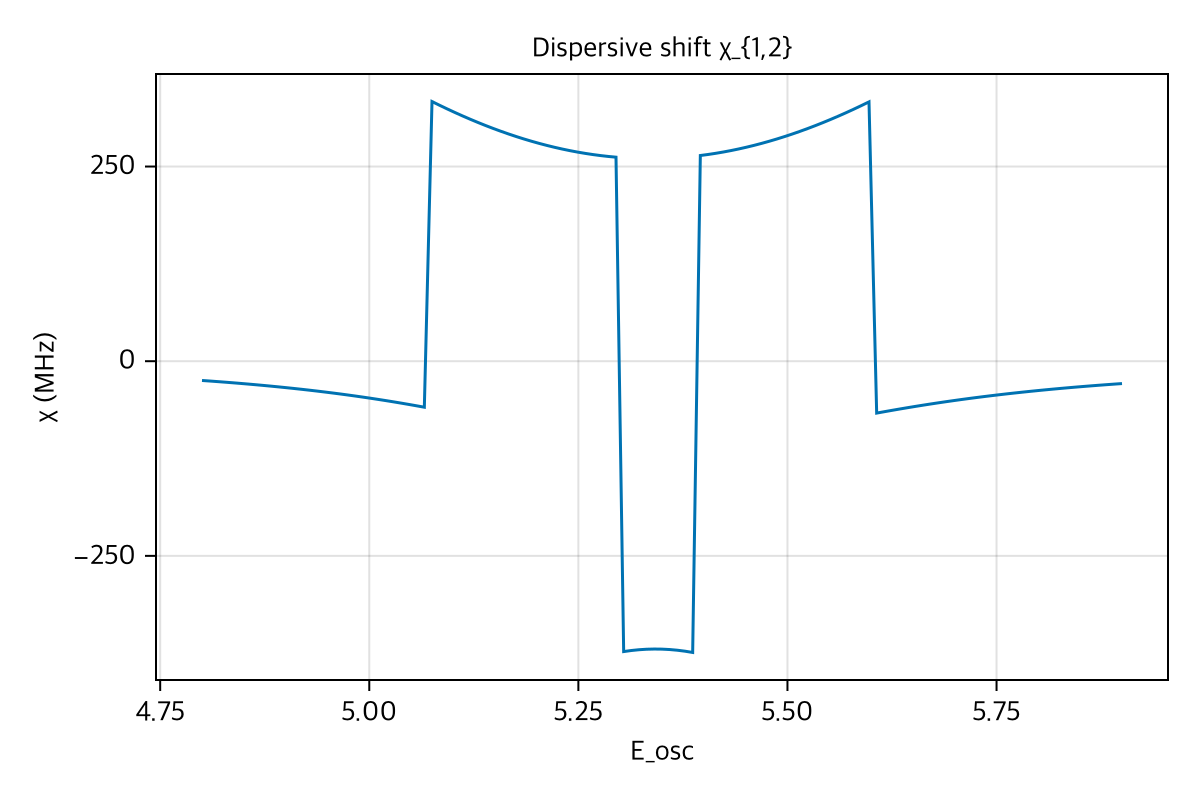

In [74]:
plot_chi_vs_paramvals(relaxed_sweep; subsys_pair=(1, 2), param_name=:E_osc)


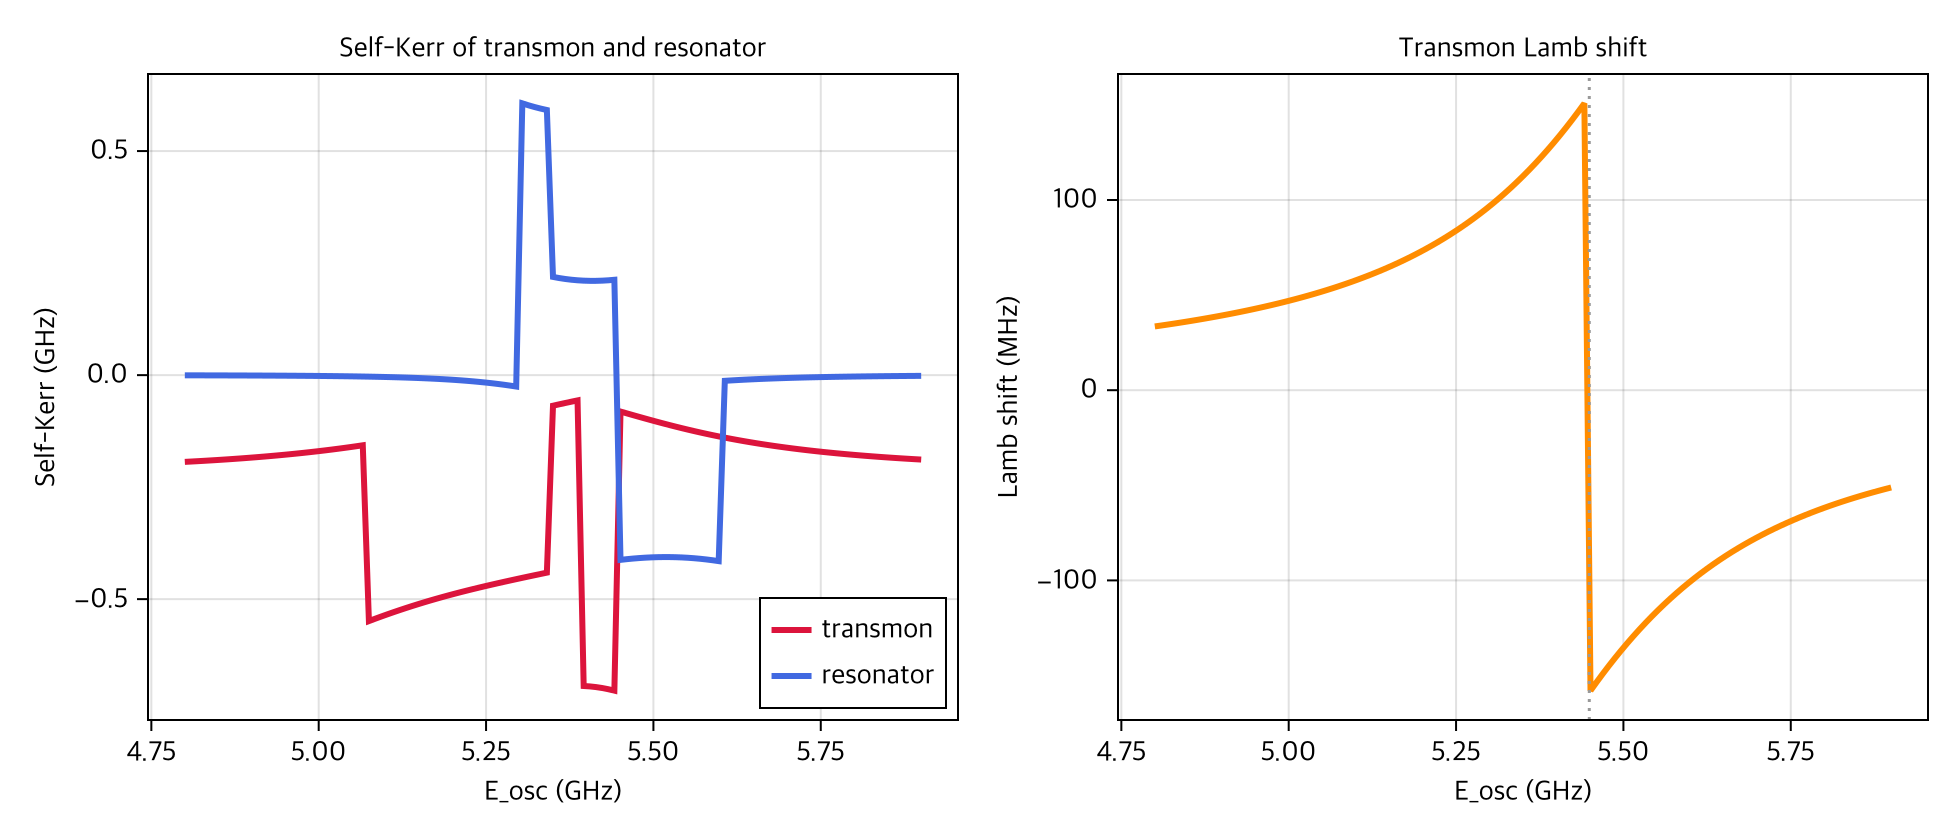

In [75]:
fig = Figure(size=(980, 420))

ax1 = Axis(fig[1, 1],
    xlabel="E_osc (GHz)",
    ylabel="Self-Kerr (GHz)",
    title="Self-Kerr of transmon and resonator")
lines!(ax1, sweep_Eosc, K_tmon; color=:crimson, linewidth=3, label="transmon")
lines!(ax1, sweep_Eosc, K_osc; color=:royalblue, linewidth=3, label="resonator")
axislegend(ax1; position=:rb)

ax2 = Axis(fig[1, 2],
    xlabel="E_osc (GHz)",
    ylabel="Lamb shift (MHz)",
    title="Transmon Lamb shift")
lines!(ax2, sweep_Eosc, ΔL .* 1000; color=:darkorange, linewidth=3)
vlines!(ax2, [ω01]; color=:gray60, linestyle=:dot)

fig


Sharp bends or apparent sign/branch changes in the self-Kerr curves near `E_osc ≈ ω01` mostly reflect hybridization and label sensitivity. In that region the exact dressed spectrum is the more trustworthy description; subsystem-level Kerr language becomes only approximate.



In [76]:
## 7. Near-resonant labeling and follow-up extensions

When the readout resonator comes too close to the transmon, there is a region where bare labels are no longer globally well defined. In that regime it is natural for the strict lookup to fail for some dispersive quantities, and the practical fix is to combine `ignore_low_overlap=true` with a sufficiently large `evals_count`.

That fix should be read as a pragmatic tracking choice, not as proof that the resulting quantities remain strict subsystem observables. Near the avoided crossing, the exact dressed spectrum is the authoritative description, while label-derived dispersive quantities should be interpreted cautiously.



UndefVarError: UndefVarError: `When` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Branch Analysis form [Dumans2024]

Dispersive limit $n_{\text{crit}}$이 아닌 branch analysis (Dumas2024)를 통해 얻는 $n_{\text{crit},i_t}$.

Branch analysis associates the eigenstates with bare product state labels $(t,r)$, with $t$ and $r$ being the **excitations** in the transmon and resonator, respectively.

1. Identifying eigenstate with the largest overlap with a bare product state $\ket{0,0}$ $\ket{\overline{0,0}}$
2. For each bare label $(0,r)$, we find the corresponding eigenstate $\ket{\overline{0,r}}$ recursively, starting from $r=1$:
    a. 
    b.
    c.
    d.
3. To find other barches with different transmon excitations. we repeat the step 2 for differnt initial eigenstates

## Iteration with Specific Ordering

`subsys_priority`



$$C_{\overline{i_t,N_r}}(\lambda)\equiv |\braket{\lambda|\hat{a}^\dagger| \overline{i_t, n_r} }|^2$$
At each step $\ket{\lambda}$ is taken from the set of unassinged states.
In this way, We obtain branches labeled $B_i$ corresponding to the set of eigenstates $\set{\ket{\overline{i_t,n_r}}}$ with fixed $i_t$ and with $n_r$ spanning the full resonator Hilbert space.

Thus, when the dispersive approximation is valid, each such branch can e pictured as an effective oscillator responding at the pulled resonator frequency associated with the transmon state $i_t$.

Average transmon population
$$N_t(i_t, n_r) \equiv \sum_{j_t, m_r}j_t |\braket{j_t, m_r| \overline{i_t, n_r}}|^2$$

Average resonator population
$$N_r(i_t,n_r)\equiv \braket{\overline{i_t, n_r}|\hat{a}^\dagger \hat{a} | \overline{i_t, n_r} }$$

## Negative detuning $\omega_q < \omega_r$ 
(i) Because of the transmon's negative anharmonicity, there generarlly exists a transmon state $i_t^*$ for which the dispersive approximation breaks down at a very low photon number. This results in 

In [ ]:



sweep_lx = ParameterSweep(hs,
    Dict(:flux => comparison_flux),
    comparison_update;
    evals_count=comparison_evals_count,
    store_lookups=true,
    deepcopy=true,
    labeling_scheme=:LX,
    labeling_subsys_priority=comparison_priority)

UndefVarError: UndefVarError: `comparison_flux` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## 8. Branch Analysis Add-on for Dumas et al. FIG 2

This append-only section adds a qualitative hybrid reproduction of the branch-analysis viewpoint used in Dumas et al. (2024) for Fig. 2. The branch labeling is built with `labeling_scheme=:LX`.

We choose `labeling_subsys_priority=[1, 2]`, so the resonator is the last subsystem in the lexical ordering and each branch corresponds to a fixed transmon excitation with increasing resonator excitation.

This is intentionally a reduced-basis reproduction. In the current Julia implementation, `:LX` requires a complete dressed eigensystem over the native subsystem basis, so the branch-analysis block uses smaller basis sizes than the main notebook model to keep the lookup feasible while preserving the qualitative branch-analysis structure.

In [60]:
using ScQubitsMimic
using CairoMakie

branch_EC = 0.22
branch_EJ = 24.2
branch_ng = 0.0
branch_ωr = 7.5
branch_g = 0.12

branch_ncut = 10 #charge basis cutoff
branch_osc_dim = 200
branch_priority = [1, 2]

branch_tmon = Transmon(EJ=branch_EJ, EC=branch_EC, ng=branch_ng, ncut=branch_ncut, truncated_dim=17)
branch_osc = Oscillator(E_osc=branch_ωr, truncated_dim=branch_osc_dim)
branch_hs = HilbertSpace([branch_tmon, branch_osc])
add_interaction!(branch_hs, branch_g, [branch_tmon, branch_osc],
    [s -> n_operator(s),
     s -> 1im * (creation_operator(s) - annihilation_operator(s))])

branch_evals_count = hilbertdim(branch_tmon) * hilbertdim(branch_osc)
branch_sweep = ParameterSweep(branch_hs,
    Dict(:anchor => [0.0]),
    (hs, vals) -> nothing;
    evals_count=branch_evals_count,
    deepcopy=true,
    store_lookups=true,
    labeling_scheme=:LX,
    labeling_subsys_priority=branch_priority)

(
    branch_labeling_scheme = branch_sweep.labeling_scheme,
    branch_labeling_subsys_priority = branch_sweep.labeling_subsys_priority,
    branch_lookup_size = length(branch_sweep.lookups[1].bare_to_dressed),
    branch_evals_count = branch_evals_count,
)

(branch_labeling_scheme = :LX, branch_labeling_subsys_priority = [1, 2], branch_lookup_size = 4200, branch_evals_count = 4200)

In [61]:
branch_rows = NamedTuple[]
branch_highlight_indices = [1, 2, 8, 11]

for it in 1:hilbertdim(branch_tmon)
    for nr in 1:hilbertdim(branch_osc)
        branch_dressed_idx = dressed_index(branch_sweep, it, nr; param_indices=(1,))
        isnothing(branch_dressed_idx) && continue

        branch_E_rel_GHz = energy_by_bare_index(branch_sweep, it, nr; param_indices=(1,), subtract_ground=true)
        branch_E_mod_GHz = mod(branch_E_rel_GHz + branch_ωr / 2, branch_ωr) - branch_ωr / 2
        branch_components = dressed_state_components(branch_sweep, (it, nr); param_indices=(1,))
        branch_N_t_avg = sum((bare[1] - 1) * p for (bare, p) in branch_components)
        branch_N_r_avg = sum((bare[2] - 1) * p for (bare, p) in branch_components)

        push!(branch_rows, (
            branch_label = "B$(it - 1)_t",
            transmon_level = it - 1,
            resonator_level = nr - 1,
            dressed_idx = branch_dressed_idx,
            N_t_avg = branch_N_t_avg,
            N_r_avg = branch_N_r_avg,
            E_rel_GHz = branch_E_rel_GHz,
            E_mod_GHz = branch_E_mod_GHz,
        ))
    end
end

branch_available_highlight_indices = sort(unique(row.transmon_level + 1 for row in branch_rows if (row.transmon_level + 1) in branch_highlight_indices))

(
    branch_row_count = length(branch_rows),
    branch_available_highlights = ["B$(idx - 1)_t" for idx in branch_available_highlight_indices],
    branch_first_rows = first(branch_rows, min(6, length(branch_rows))),
)

(branch_row_count = 4200, branch_available_highlights = ["B0_t", "B1_t", "B7_t", "B10_t"], branch_first_rows = NamedTuple[(branch_label = "B0_t", transmon_level = 0, resonator_level = 0, dressed_idx = 1, N_t_avg = 0.00013566290433584475, N_r_avg = 0.00013559002107500754, E_rel_GHz = 0.0, E_mod_GHz = 0.0), (branch_label = "B0_t", transmon_level = 0, resonator_level = 1, dressed_idx = 3, N_t_avg = 0.01721241772488265, N_r_avg = 0.9833268646959018, E_rel_GHz = 7.519206382522896, E_mod_GHz = 0.019206382522895638), (branch_label = "B0_t", transmon_level = 0, resonator_level = 2, dressed_idx = 6, N_t_avg = 0.03403961023688394, N_r_avg = 1.96676818344885, E_rel_GHz = 15.038324940406762, E_mod_GHz = 0.03832494040675982), (branch_label = "B0_t", transmon_level = 0, resonator_level = 3, dressed_idx = 10, N_t_avg = 0.05062507941434972, N_r_avg = 2.950451700209274, E_rel_GHz = 22.55735726150338, E_mod_GHz = 0.057357261503380386), (branch_label = "B0_t", transmon_level = 0, resonator_level = 4, dre

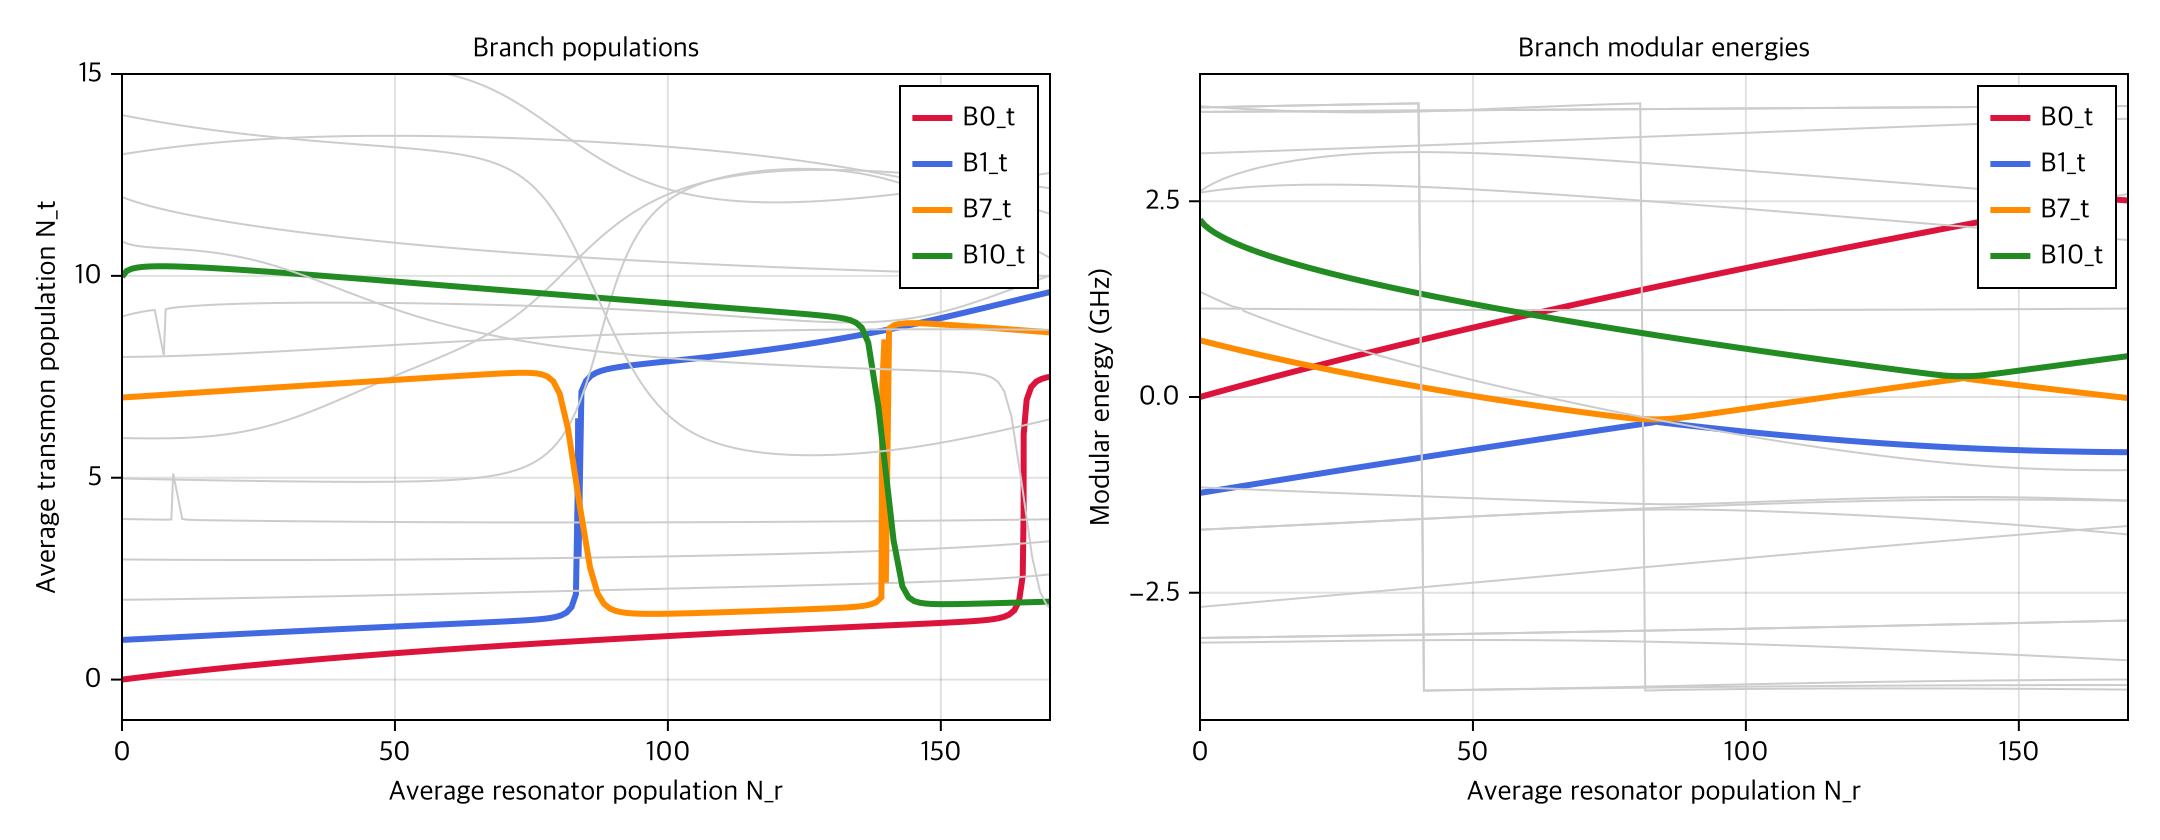

In [65]:
branch_highlight_colors = Dict(1 => :crimson, 2 => :royalblue, 8 => :darkorange, 11 => :forestgreen)
branch_group_levels = sort(unique(row.transmon_level for row in branch_rows))

branch_fig = Figure(size=(1080, 420))
branch_ax1 = Axis(branch_fig[1, 1],
    xlabel="Average resonator population N_r",
    ylabel="Average transmon population N_t",
    title="Branch populations")
xlims!(branch_ax1, 0, 170)
ylims!(branch_ax1, -1, 15)

branch_ax2 = Axis(branch_fig[1, 2],
    xlabel="Average resonator population N_r",
    ylabel="Modular energy (GHz)",
    title="Branch modular energies")
xlims!(branch_ax2, 0, 170)

for branch_level in branch_group_levels
    branch_rows_level = sort(filter(row -> row.transmon_level == branch_level, branch_rows); by=row -> row.N_r_avg)
    branch_idx = branch_level + 1

    if branch_idx in keys(branch_highlight_colors)
        branch_color = branch_highlight_colors[branch_idx]
        branch_label = first(branch_rows_level).branch_label
        lines!(branch_ax1, [row.N_r_avg for row in branch_rows_level], [row.N_t_avg for row in branch_rows_level];
            color=branch_color, linewidth=3, label=branch_label)
        lines!(branch_ax2, [row.N_r_avg for row in branch_rows_level], [row.E_mod_GHz for row in branch_rows_level];
            color=branch_color, linewidth=3, label=branch_label)
    else
        lines!(branch_ax1, [row.N_r_avg for row in branch_rows_level], [row.N_t_avg for row in branch_rows_level];
            color=:gray80, linewidth=1)
        lines!(branch_ax2, [row.N_r_avg for row in branch_rows_level], [row.E_mod_GHz for row in branch_rows_level];
            color=:gray80, linewidth=1)
    end
end

axislegend(branch_ax1; position=:rt)
axislegend(branch_ax2; position=:rt)

branch_fig

In [63]:
branch_summary_table = begin
    branch_rows_summary = NamedTuple[]
    for branch_idx in branch_available_highlight_indices
        branch_rows_level = sort(filter(row -> row.transmon_level + 1 == branch_idx, branch_rows); by=row -> row.N_r_avg)
        isempty(branch_rows_level) && continue

        branch_first = first(branch_rows_level)
        branch_last = last(branch_rows_level)
        push!(branch_rows_summary, (
            branch_label = branch_first.branch_label,
            N_r_start = branch_first.N_r_avg,
            N_t_start = branch_first.N_t_avg,
            E_mod_start_GHz = branch_first.E_mod_GHz,
            N_r_end = branch_last.N_r_avg,
            N_t_end = branch_last.N_t_avg,
            E_mod_end_GHz = branch_last.E_mod_GHz,
        ))
    end
    branch_rows_summary
end

branch_summary_table

4-element Vector{NamedTuple}:
 (branch_label = "B0_t", N_r_start = 0.00013559002107500754, N_t_start = 0.00013566290433584475, E_mod_start_GHz = 0.0, N_r_end = 194.26592499826847, N_t_end = 7.736406360678114, E_mod_end_GHz = 2.435479027844849)
 (branch_label = "B1_t", N_r_start = 0.01721431978725492, N_t_start = 0.9833296797239117, E_mod_start_GHz = -1.2247787325393418, N_r_end = 193.10809142058363, N_t_end = 10.260308694446103, E_mod_end_GHz = -0.7119019043620938)
 (branch_label = "B7_t", N_r_start = 0.015137031802713053, N_t_start = 6.987072829423137, E_mod_start_GHz = 0.7233786726263247, N_r_end = 197.0238569870843, N_t_end = 8.821624170103632, E_mod_end_GHz = 1.910333057441676)
 (branch_label = "B10_t", N_r_start = 0.009813095102388134, N_t_start = 9.981202902393681, E_mod_start_GHz = 2.2634786285485973, N_r_end = 198.06422435359215, N_t_end = 8.481348228370347, E_mod_end_GHz = -1.6196934283384508)